# Assignment 5 notebook:

This notebook supports the investigation in Assignment 5.

It does the following:

1. implements the square spiral labelling;
2. enumerates self-avoiding walks of short length from the square labelled $1$;
3. records the attainable residues modulo $10$ and the number of walks with value congruent to $5 \pmod{10}$;
4. checks the constructive families used in the write-up.
5. generate the graph for my proof

## Conventions

- The square labelled $1$ is placed at the origin $(0,0)$.
- The square labelled $2$ is at $(1,0)$, and the spiral proceeds anticlockwise.
- A walk starts at $(0,0)$ but the label $1$ is **not** included in the value.
- The value of a walk is the sum of the labels of the entered squares.

In [75]:
from collections import defaultdict
from functools import lru_cache
from math import isqrt
import pandas as pd
import matplotlib.pyplot as plt

## Spiral coordinate and label functions

In [76]:
@lru_cache(maxsize=None)
def coord_of(n: int) -> tuple[int, int]:
    if n < 1:
        raise ValueError("n must be positive")
    if n == 1:
        return (0, 0)

    r = (isqrt(n - 1) + 1) // 2
    m = (2 * r + 1) ** 2
    d = m - n

    if d <= 2 * r:
        return (r - d, -r)
    elif d <= 4 * r:
        d -= 2 * r
        return (-r, -r + d)
    elif d <= 6 * r:
        d -= 4 * r
        return (-r + d, r)
    else:
        d -= 6 * r
        return (r, r - d)

@lru_cache(maxsize=None)
def label_of(x: int, y: int) -> int:
    r = max(abs(x), abs(y))
    if r == 0:
        return 1

    m = (2 * r + 1) ** 2
    if y == -r:
        return m - (r - x)
    elif x == -r:
        return m - 2 * r - (y + r)
    elif y == r:
        return m - 4 * r - (x + r)
    else:
        return m - 6 * r - (r - y)

In [77]:
# Quick sanity check
first_n = 25
check = [(n, coord_of(n), label_of(*coord_of(n))) for n in range(1, first_n + 1)]
assert all(n == back for n, _, back in check)
check[:10]

[(1, (0, 0), 1),
 (2, (1, 0), 2),
 (3, (1, 1), 3),
 (4, (0, 1), 4),
 (5, (-1, 1), 5),
 (6, (-1, 0), 6),
 (7, (-1, -1), 7),
 (8, (0, -1), 8),
 (9, (1, -1), 9),
 (10, (2, -1), 10)]

## A small picture of the spiral

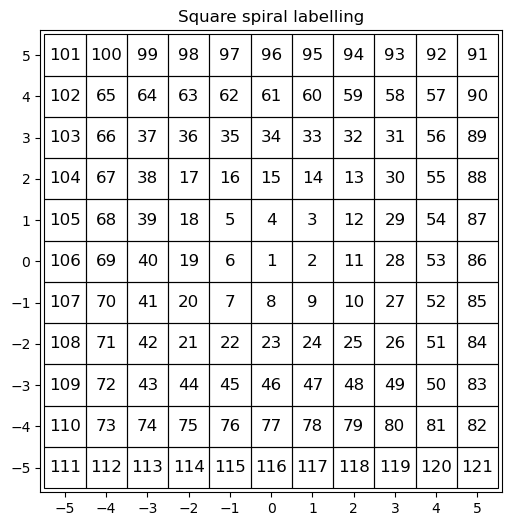

In [78]:
def plot_spiral(window=2):
    fig, ax = plt.subplots(figsize=(6, 6))
    for x in range(-window, window + 1):
        for y in range(-window, window + 1):
            ax.add_patch(plt.Rectangle((x - 0.5, y - 0.5), 1, 1, fill=False, linewidth=0.8))
            ax.text(x, y, str(label_of(x, y)), ha="center", va="center", fontsize=12)
    ax.set_aspect("equal")
    ax.set_xlim(-window - 0.6, window + 0.6)
    ax.set_ylim(-window - 0.6, window + 0.6)
    ax.set_xticks(range(-window, window + 1))
    ax.set_yticks(range(-window, window + 1))
    ax.set_title("Square spiral labelling")
    plt.show()

plot_spiral(window=5)

## Walks and their values

In [79]:
DIRS = {
    "E": (1, 0),
    "W": (-1, 0),
    "N": (0, 1),
    "S": (0, -1),
}

def neighbours(p):
    x, y = p
    for dx, dy in DIRS.values():
        yield (x + dx, y + dy)

def walk_from_word(word: str):
    pos = (0, 0)
    path = [pos]
    value = 0
    seen = {pos}
    for ch in word:
        dx, dy = DIRS[ch]
        pos = (pos[0] + dx, pos[1] + dy)
        if pos in seen:
            raise ValueError(f"word {word!r} is not self-avoiding")
        seen.add(pos)
        path.append(pos)
        value += label_of(*pos)
    return path, value

def residue_of_word(word: str, mod=10):
    return walk_from_word(word)[1] % mod

In [80]:
for word in ["E", "EN", "ENN", "EENN", "ENEN"]:
    path, value = walk_from_word(word)
    print(f"{word:6s} value = {value:3d}, residue mod 10 = {value % 10}")

E      value =   2, residue mod 10 = 2
EN     value =   5, residue mod 10 = 5
ENN    value =  19, residue mod 10 = 9
EENN   value =  38, residue mod 10 = 8
ENEN   value =  30, residue mod 10 = 0


## Exhaustive enumeration of short self-avoiding walks

In [81]:
def enumerate_walk_statistics(max_len=12, mod=10):
    residues_by_len = {L: set() for L in range(1, max_len + 1)}
    count_residue_by_len = {L: defaultdict(int) for L in range(1, max_len + 1)}
    total_walks_by_len = defaultdict(int)

    start = (0, 0)

    def dfs(pos, seen, length, value):
        if 1 <= length <= max_len:
            residue = value % mod
            residues_by_len[length].add(residue)
            count_residue_by_len[length][residue] += 1
            total_walks_by_len[length] += 1

        if length == max_len:
            return

        for nxt in neighbours(pos):
            if nxt in seen:
                continue
            seen.add(nxt)
            dfs(nxt, seen, length + 1, value + label_of(*nxt))
            seen.remove(nxt)

    dfs(start, {start}, 0, 0)
    return residues_by_len, count_residue_by_len, total_walks_by_len

In [82]:
MAX_LEN = 12
residues_by_len, count_residue_by_len, total_walks_by_len = enumerate_walk_statistics(MAX_LEN)

In [83]:
table_rows = []
for L in range(1, MAX_LEN + 1):
    realised = sorted(residues_by_len[L])
    table_rows.append({
        "length": L,
        "realised residues": realised,
        "number of walks": total_walks_by_len[L],
        "count with value ≡ 5 (mod 10)": count_residue_by_len[L][5],
    })

table = pd.DataFrame(table_rows)
table

,length,realised residues,number of walks,count with value ≡ 5 (mod 10)
0,1,"[2, 4, 6, 8]",4,0
1,2,"[1, 3, 5, 7, 9]",12,3
2,3,"[1, 3, 5, 7, 9]",36,11
3,4,"[0, 2, 4, 6, 8]",100,0
4,5,"[0, 2, 4, 6, 8]",284,0
5,6,"[1, 3, 5, 7, 9]",780,165
6,7,"[1, 3, 5, 7, 9]",2172,420
7,8,"[0, 2, 4, 6, 8]",5916,0
8,9,"[0, 2, 4, 6, 8]",16268,0
9,10,"[1, 3, 5, 7, 9]",44100,8834


In [84]:
def predicted_parity(L):
    return (L // 2) % 2

parity_check = []
for L in range(1, MAX_LEN + 1):
    actual_parities = sorted({r % 2 for r in residues_by_len[L]})
    parity_check.append({
        "length": L,
        "predicted parity of walk value": predicted_parity(L),
        "actual parities realised": actual_parities,
        "all residues match prediction": actual_parities == [predicted_parity(L)],
    })

pd.DataFrame(parity_check)

,length,predicted parity of walk value,actual parities realised,all residues match prediction
0,1,0,[0],True
1,2,1,[1],True
2,3,1,[1],True
3,4,0,[0],True
4,5,0,[0],True
5,6,1,[1],True
6,7,1,[1],True
7,8,0,[0],True
8,9,0,[0],True
9,10,1,[1],True


## Counts by residue

In [85]:
rows = []
for L in range(1, MAX_LEN + 1):
    row = {"length": L}
    for r in range(10):
        row[r] = count_residue_by_len[L][r]
    rows.append(row)

counts_table = pd.DataFrame(rows).set_index("length")
counts_table

,0,1,2,3,4,5,6,7,8,9
length,,,,,,,,,,
1,0,0,1,0,1,0,1,0,1,0
2,0,3,0,2,0,3,0,2,0,2
3,0,6,0,6,0,11,0,6,0,7
4,19,0,20,0,23,0,19,0,19,0
5,62,0,49,0,52,0,67,0,54,0
6,0,153,0,141,0,165,0,168,0,153
7,0,434,0,409,0,420,0,443,0,466
8,1179,0,1183,0,1161,0,1179,0,1214,0
9,3270,0,3270,0,3228,0,3284,0,3216,0


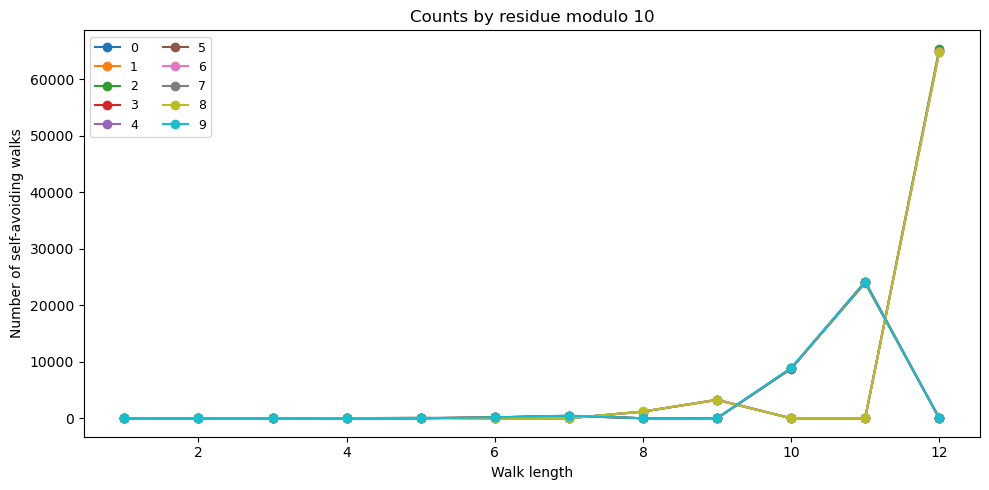

In [86]:
fig, ax = plt.subplots(figsize=(10, 5))
for r in range(10):
    ax.plot(counts_table.index, counts_table[r], marker="o", label=f"{r}")
ax.set_xlabel("Walk length")
ax.set_ylabel("Number of self-avoiding walks")
ax.set_title("Counts by residue modulo 10")
ax.legend(ncol=2, fontsize=9)
plt.tight_layout()
plt.show()

## Constructive seed paths used in the write-up

To prove that every residue of the correct parity occurs, the written argument uses two small families of monotone paths:

- length $4$ paths from $(0,0)$ to $(2,2)$ covering all even residues;
- length $6$ paths from $(0,0)$ to $(3,3)$ covering all odd residues.

In [87]:
even_seed_words = ["EENN", "ENEN", "ENNE", "NENE", "NNEE"]
odd_seed_words  = ["EEENNN", "ENENNE", "EENENN", "ENEENN", "EENNEN"]

even_seed_table = pd.DataFrame({
    "word": even_seed_words,
    "value": [walk_from_word(w)[1] for w in even_seed_words],
    "residue mod 10": [residue_of_word(w) for w in even_seed_words],
})
odd_seed_table = pd.DataFrame({
    "word": odd_seed_words,
    "value": [walk_from_word(w)[1] for w in odd_seed_words],
    "residue mod 10": [residue_of_word(w) for w in odd_seed_words],
})

print("Even seeds:")
display(even_seed_table)
print("Odd seeds:")
display(odd_seed_table)

Even seeds:


,word,value,residue mod 10
0,EENN,38,8
1,ENEN,30,0
2,ENNE,32,2
3,NENE,34,4
4,NNEE,46,6


Odd seeds:


,word,value,residue mod 10
0,EEENNN,131,1
1,ENENNE,93,3
2,EENENN,115,5
3,ENEENN,107,7
4,EENNEN,99,9


## Appending a common tail

In [88]:
def append_east_tail(word: str, extra_steps: int) -> tuple[str, int]:
    new_word = word + "E" * extra_steps
    path, value = walk_from_word(new_word)
    return new_word, value

def residues_from_extended_family(seed_words, extra_steps):
    return sorted({append_east_tail(w, extra_steps)[1] % 10 for w in seed_words})

In [89]:
test_rows = []
for extra_steps in range(0, 8):
    L_even = 4 + extra_steps
    L_odd = 6 + extra_steps
    test_rows.append({
        "extra east steps": extra_steps,
        "length from even seeds": L_even,
        "residues from even-seed family": residues_from_extended_family(even_seed_words, extra_steps),
        "predicted parity": predicted_parity(L_even),
        "length from odd seeds": L_odd,
        "residues from odd-seed family": residues_from_extended_family(odd_seed_words, extra_steps),
        "predicted parity (odd family length)": predicted_parity(L_odd),
    })

pd.DataFrame(test_rows)

,extra east steps,length from even seeds,residues from even-seed family,predicted parity,length from odd seeds,residues from odd-seed family,predicted parity (odd family length)
0,0,4,"[0, 2, 4, 6, 8]",0,6,"[1, 3, 5, 7, 9]",1
1,1,5,"[0, 2, 4, 6, 8]",0,7,"[1, 3, 5, 7, 9]",1
2,2,6,"[1, 3, 5, 7, 9]",1,8,"[0, 2, 4, 6, 8]",0
3,3,7,"[1, 3, 5, 7, 9]",1,9,"[0, 2, 4, 6, 8]",0
4,4,8,"[0, 2, 4, 6, 8]",0,10,"[1, 3, 5, 7, 9]",1
5,5,9,"[0, 2, 4, 6, 8]",0,11,"[1, 3, 5, 7, 9]",1
6,6,10,"[1, 3, 5, 7, 9]",1,12,"[0, 2, 4, 6, 8]",0
7,7,11,"[1, 3, 5, 7, 9]",1,13,"[0, 2, 4, 6, 8]",0


## Explicit examples with value congruent to $5 \pmod{10}$

In [90]:
examples_mod_5 = []

def find_first_word_of_length(target_length, target_residue=5):
    start = (0, 0)
    answer = None

    def dfs(pos, seen, length, value, word):
        nonlocal answer
        if answer is not None:
            return
        if length == target_length:
            if value % 10 == target_residue:
                answer = (word, value)
            return
        for ch, (dx, dy) in DIRS.items():
            nxt = (pos[0] + dx, pos[1] + dy)
            if nxt in seen:
                continue
            seen.add(nxt)
            dfs(nxt, seen, length + 1, value + label_of(*nxt), word + ch)
            seen.remove(nxt)

    dfs(start, {start}, 0, 0, "")
    return answer

for L in range(2, 13):
    if L % 4 in (2, 3):
        word, value = find_first_word_of_length(L, 5)
        examples_mod_5.append({
            "length": L,
            "word": word,
            "value": value,
            "value mod 10": value % 10,
        })

pd.DataFrame(examples_mod_5)

,length,word,value,value mod 10
0,2,EN,5,5
1,3,EEN,25,5
2,6,EEEEES,265,5
3,7,EEEEEEN,435,5
4,10,EEEEEEEEEE,1385,5
5,11,EEEEEEEEEES,1755,5


## Compact verification of the classification

For the explored range, the data matches

$$
\mathcal{R}_\ell
=
r \in \mathbb{Z}/10\mathbb{Z} : r \equiv \lfloor \ell/2 \rfloor \pmod 2.
$$

In [91]:
verification_rows = []
for L in range(1, MAX_LEN + 1):
    predicted = [r for r in range(10) if r % 2 == predicted_parity(L)]
    actual = sorted(residues_by_len[L])
    verification_rows.append({
        "length": L,
        "predicted residues": predicted,
        "actual residues": actual,
        "match": predicted == actual,
    })

pd.DataFrame(verification_rows)

,length,predicted residues,actual residues,match
0,1,"[0, 2, 4, 6, 8]","[2, 4, 6, 8]",False
1,2,"[1, 3, 5, 7, 9]","[1, 3, 5, 7, 9]",True
2,3,"[1, 3, 5, 7, 9]","[1, 3, 5, 7, 9]",True
3,4,"[0, 2, 4, 6, 8]","[0, 2, 4, 6, 8]",True
4,5,"[0, 2, 4, 6, 8]","[0, 2, 4, 6, 8]",True
5,6,"[1, 3, 5, 7, 9]","[1, 3, 5, 7, 9]",True
6,7,"[1, 3, 5, 7, 9]","[1, 3, 5, 7, 9]",True
7,8,"[0, 2, 4, 6, 8]","[0, 2, 4, 6, 8]",True
8,9,"[0, 2, 4, 6, 8]","[0, 2, 4, 6, 8]",True
9,10,"[1, 3, 5, 7, 9]","[1, 3, 5, 7, 9]",True


## Proof diagram

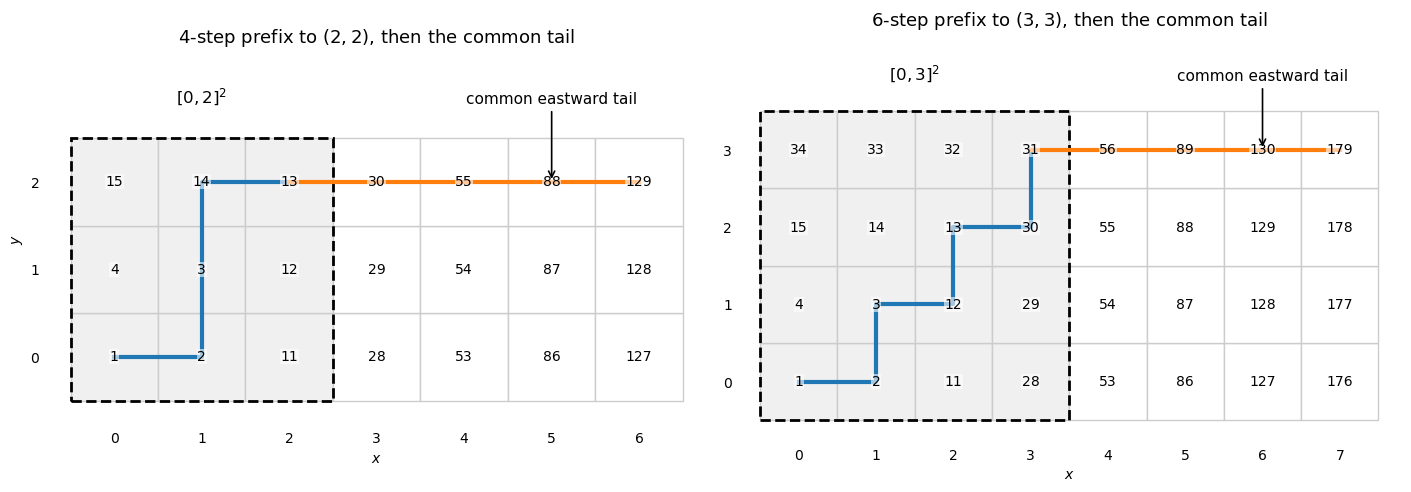

In [ ]:
def spiral_label(x, y):
    if x == 0 and y == 0:
        return 1

    r = max(abs(x), abs(y))

    if x == r and y != -r:
        return 4*r*r - 3*r + y + 1

    if y == r:
        return 4*r*r - r + 1 - x

    if x == -r:
        return 4*r*r + r + 1 - y

    return 4*r*r + 3*r + 1 + x

def draw_seed_tail_panel(ax, prefix, tail_length, box_max, title):

    endpoint = prefix[-1]
    tail = [(endpoint[0] + k, endpoint[1]) for k in range(1, tail_length + 1)]

    x_max = endpoint[0] + tail_length
    y_max = max(box_max, endpoint[1])

    for x in range(0, x_max + 1):
        for y in range(0, y_max + 1):
            inside_box = (0 <= x <= box_max and 0 <= y <= box_max)
            face = "0.94" if inside_box else "1.0"

            ax.add_patch(
                Rectangle(
                    (x - 0.5, y - 0.5),
                    1, 1,
                    facecolor=face,
                    edgecolor="0.8",
                    linewidth=1
                )
            )

    ax.add_patch(
        Rectangle(
            (-0.5, -0.5),
            box_max + 1,
            box_max + 1,
            fill=False,
            linestyle="--",
            linewidth=2
        )
    )
    ax.text(
        box_max / 2,
        box_max + 0.85,
        rf"$[0,{box_max}]^2$",
        ha="center",
        va="bottom",
        fontsize=12
    )

    px, py = zip(*prefix)
    ax.plot(px, py, linewidth=3)

    tx = [endpoint[0]] + [p[0] for p in tail]
    ty = [endpoint[1]] + [p[1] for p in tail]
    ax.plot(tx, ty, linewidth=3)

    for x in range(0, x_max + 1):
        for y in range(0, y_max + 1):
            ax.text(
                x, y, str(spiral_label(x, y)),
                ha="center", va="center", fontsize=10,
                bbox=dict(facecolor="white", edgecolor="none", alpha=0.6, pad=0.25)
            )

    tail_point = (tx[-2], ty[-2]) if len(tx) >= 2 else (tx[-1], ty[-1])
    ax.annotate(
        "common eastward tail",
        xy=tail_point,
        xytext=(tail_point[0], tail_point[1] + 0.9),
        ha="center",
        arrowprops=dict(arrowstyle="->", lw=1.2),
        fontsize=11
    )

    ax.set_title(title, fontsize=13)
    ax.set_aspect("equal")
    ax.set_xlim(-0.8, x_max + 0.8)
    ax.set_ylim(-0.8, y_max + 1.5)
    ax.set_xticks(range(0, x_max + 1))
    ax.set_yticks(range(0, y_max + 1))
    ax.tick_params(length=0)
    ax.grid(False)

    for spine in ax.spines.values():
        spine.set_visible(False)

prefix_4 = [
    (0, 0),
    (1, 0),
    (1, 1),
    (1, 2),
    (2, 2),
]

prefix_6 = [
    (0, 0),
    (1, 0),
    (1, 1),
    (2, 1),
    (2, 2),
    (3, 2),
    (3, 3),
]


fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), constrained_layout=True)

draw_seed_tail_panel(
    axes[0],
    prefix=prefix_4,
    tail_length=tail_length,
    box_max=2,
    title=r"4-step prefix to $(2,2)$, then the common tail"
)

draw_seed_tail_panel(
    axes[1],
    prefix=prefix_6,
    tail_length=tail_length,
    box_max=3,
    title=r"6-step prefix to $(3,3)$, then the common tail"
)

axes[0].set_ylabel("$y$")
for ax in axes:
    ax.set_xlabel("$x$")

plt.savefig("seed_tail_construction.png", dpi=300, bbox_inches="tight")
plt.show()

## Extension Diagrams

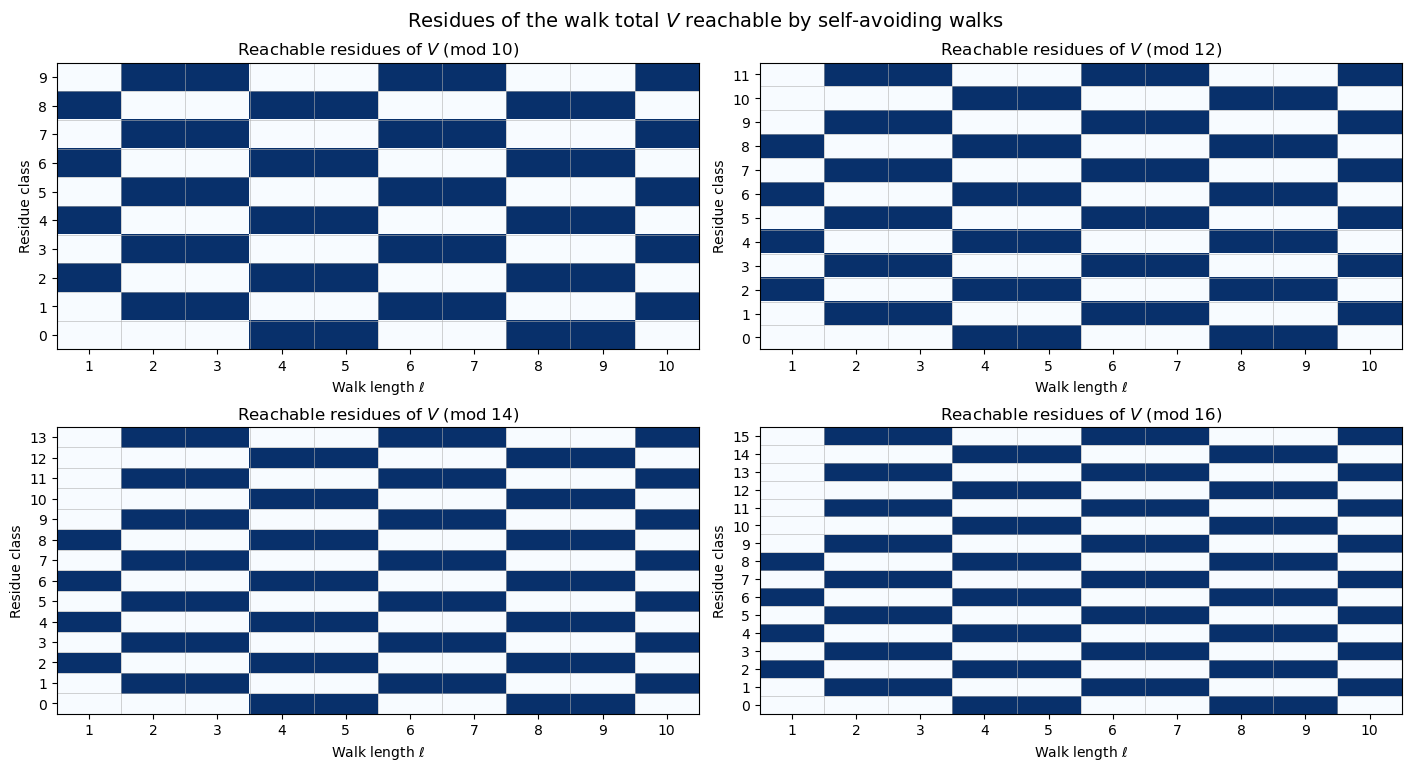

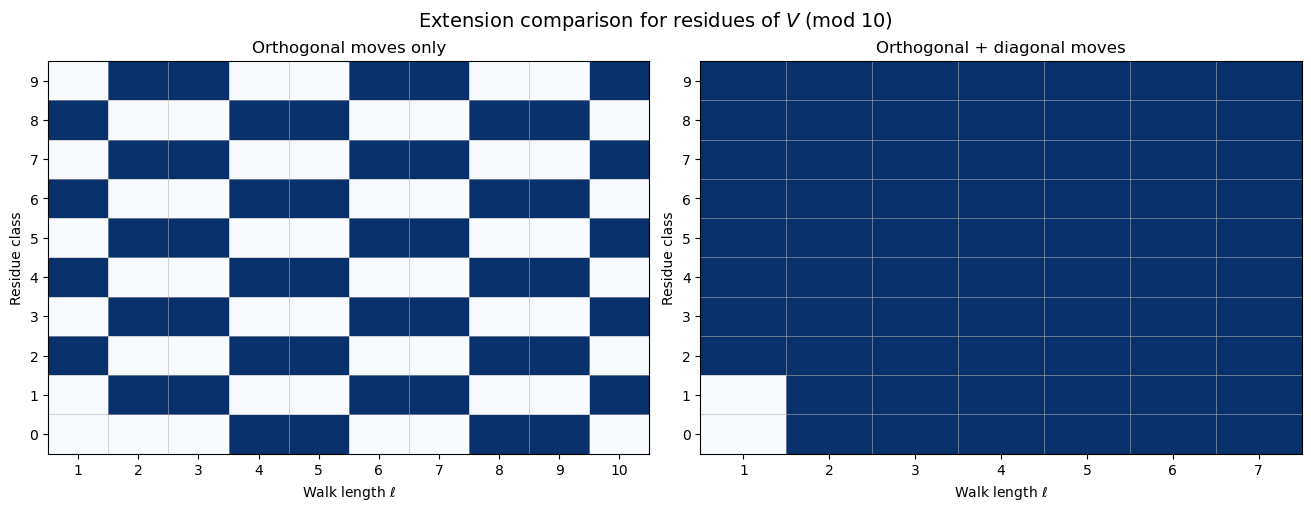

In [ ]:
ORTHOGONAL = [(1, 0), (-1, 0), (0, 1), (0, -1)]
DIAGONAL = [(1, 1), (1, -1), (-1, 1), (-1, -1)]


def spiral_labels(radius): #similar to last one but different enough to require rewriting.

    labels = {(0, 0): 1}
    x = y = 0
    current = 1
    step_len = 1
    dirs = [(1, 0), (0, 1), (-1, 0), (0, -1)]
    d = 0
    target_size = (2 * radius + 1) ** 2

    while len(labels) < target_size:
        for _ in range(2):
            dx, dy = dirs[d % 4]
            for _ in range(step_len):
                x += dx
                y += dy
                current += 1
                if max(abs(x), abs(y)) <= radius:
                    labels[(x, y)] = current
                if len(labels) == target_size:
                    break
            d += 1
            if len(labels) == target_size:
                break
        step_len += 1

    return labels


def compute_reachable_residues(moduli, max_len=10, allow_diagonal=False, radius=None):

    if radius is None:
        radius = max_len + 2

    labels = spiral_labels(radius)
    start = (0, 0)
    directions = ORTHOGONAL + (DIAGONAL if allow_diagonal else [])

    reachable = {M: [set() for _ in range(max_len + 1)] for M in moduli}

    def dfs(pos, seen, total, length):
        for M in moduli:
            reachable[M][length].add(total % M)

        if length == max_len:
            return

        x, y = pos
        for dx, dy in directions:
            nxt = (x + dx, y + dy)
            if nxt not in labels or nxt in seen:
                continue

            seen.add(nxt)
            # add the new square only; do NOT count the initial 1
            dfs(nxt, seen, total + labels[nxt], length + 1)
            seen.remove(nxt)

    # start with V = 0 and length = 0
    dfs(start, {start}, 0, 0)
    return reachable


def residue_matrix(reachable_for_modulus, modulus, max_len, include_zero=False):

    if include_zero:
        A = np.zeros((max_len + 1, modulus), dtype=int)
        for ell in range(max_len + 1):
            for r in reachable_for_modulus[ell]:
                A[ell, r] = 1
    else:
        A = np.zeros((max_len, modulus), dtype=int)
        for ell in range(1, max_len + 1):
            for r in reachable_for_modulus[ell]:
                A[ell - 1, r] = 1
    return A


def plot_generalisation_heatmaps(moduli=(10, 12, 14, 16), max_len=10):

    reachable = compute_reachable_residues(
        moduli=moduli,
        max_len=max_len,
        allow_diagonal=False
    )

    n = len(moduli)
    ncols = 2
    nrows = (n + 1) // 2

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(14, 3.8 * nrows),
        constrained_layout=True
    )
    axes = np.array(axes).reshape(-1)

    for ax, M in zip(axes, moduli):
        # transpose so that x = length and y = residue
        A = residue_matrix(reachable[M], M, max_len, include_zero=False).T

        ax.imshow(
            A,
            origin="lower",
            aspect="auto",
            interpolation="nearest",
            cmap="Blues"
        )

        ax.set_title(rf"Reachable residues of $V \;(\mathrm{{mod}}\; {M})$")
        ax.set_xlabel(r"Walk length $\ell$")
        ax.set_ylabel("Residue class")

        ax.set_xticks(range(max_len))
        ax.set_xticklabels(range(1, max_len + 1))
        ax.set_yticks(range(M))

        ax.set_xticks(np.arange(-0.5, max_len, 1), minor=True)
        ax.set_yticks(np.arange(-0.5, M, 1), minor=True)
        ax.grid(which="minor", linewidth=0.4)
        ax.tick_params(which="minor", bottom=False, left=False)

    for ax in axes[len(moduli):]:
        ax.axis("off")

    fig.suptitle(
        r"Residues of the walk total $V$ reachable by self-avoiding walks",
        fontsize=14
    )
    plt.show()


def plot_extension_comparison(modulus=10, max_len_orth=10, max_len_diag=7):
    reachable_orth = compute_reachable_residues(
        moduli=(modulus,),
        max_len=max_len_orth,
        allow_diagonal=False
    )
    reachable_diag = compute_reachable_residues(
        moduli=(modulus,),
        max_len=max_len_diag,
        allow_diagonal=True
    )

    A1 = residue_matrix(reachable_orth[modulus], modulus, max_len_orth, include_zero=False).T
    A2 = residue_matrix(reachable_diag[modulus], modulus, max_len_diag, include_zero=False).T

    fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)

    axes[0].imshow(
        A1,
        origin="lower",
        aspect="auto",
        interpolation="nearest",
        cmap="Blues"
    )
    axes[0].set_title("Orthogonal moves only")
    axes[0].set_xlabel(r"Walk length $\ell$")
    axes[0].set_ylabel("Residue class")
    axes[0].set_xticks(range(max_len_orth))
    axes[0].set_xticklabels(range(1, max_len_orth + 1))
    axes[0].set_yticks(range(modulus))
    axes[0].set_xticks(np.arange(-0.5, max_len_orth, 1), minor=True)
    axes[0].set_yticks(np.arange(-0.5, modulus, 1), minor=True)
    axes[0].grid(which="minor", linewidth=0.4)
    axes[0].tick_params(which="minor", bottom=False, left=False)

    axes[1].imshow(
        A2,
        origin="lower",
        aspect="auto",
        interpolation="nearest",
        cmap="Blues"
    )
    axes[1].set_title("Orthogonal + diagonal moves")
    axes[1].set_xlabel(r"Walk length $\ell$")
    axes[1].set_ylabel("Residue class")
    axes[1].set_xticks(range(max_len_diag))
    axes[1].set_xticklabels(range(1, max_len_diag + 1))
    axes[1].set_yticks(range(modulus))
    axes[1].set_xticks(np.arange(-0.5, max_len_diag, 1), minor=True)
    axes[1].set_yticks(np.arange(-0.5, modulus, 1), minor=True)
    axes[1].grid(which="minor", linewidth=0.4)
    axes[1].tick_params(which="minor", bottom=False, left=False)

    fig.suptitle(
        rf"Extension comparison for residues of $V \;(\mathrm{{mod}}\; {modulus})$",
        fontsize=14
    )
    plt.show()

plot_generalisation_heatmaps(moduli=(10, 12, 14, 16), max_len=10)
plot_extension_comparison(modulus=10, max_len_orth=10, max_len_diag=7)